In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import re

In [3]:
df = pd.read_csv("./data/train.csv")
df.head()

,MONTH,TOWN,FLAT_TYPE,BLOCK,STREET,FLOOR_RANGE,FLOOR_AREA_SQM,FLAT_MODEL,ECO_CATEGORY,LEASE_COMMENCE_DATA,RESALE_PRICE
0,2020-10,woodlands,4 room,681B,woodlands drive 62,07 to 09,102.0,premium apartment,uncategorized,2000,420000.0
1,2021-07,bishan,4 room,264,bishan street 24,07 to 09,104.0,model a,uncategorized,1992,585000.0
2,2021-05,bukit panjang,4 room,520,jelapang road,19 to 21,102.0,model a,uncategorized,1998,450000.0
3,2021-08,punggol,4 room,121B,edgedale plains,16 to 18,93.0,model a,uncategorized,2017,465000.0
4,2023-05,hougang,5 room,997B,Buangkok Crescent,10 to 12,113.0,improved,uncategorized,2018,710000.0


In [4]:
# Value counts for all non-numeric columns
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
for col in non_numeric_cols:
    print(f"Value counts for column: {col}")
    display(df[col].value_counts())
    print("\n" + "-"*40 + "\n")

Value counts for column: MONTH


MONTH
2024-07    2356
2021-08    2112
2024-01    2055
2024-08    2012
2018-07    2005
           ... 
2017-01     913
2017-02     839
2018-01     809
2020-04     338
2020-05     265
Name: count, Length: 103, dtype: int64


----------------------------------------

Value counts for column: TOWN


TOWN
sengkang           13335
punggol            11925
woodlands          11506
yishun             11175
tampines           11030
jurong west        10781
bedok               8457
hougang             8120
choa chu kang       7397
bukit batok         6733
ang mo kio          6623
bukit merah         6184
bukit panjang       5891
toa payoh           5182
kallang/whampoa     4994
sembawang           4828
pasir ris           4737
queenstown          4391
geylang             3995
clementi            3599
jurong east         3364
serangoon           2884
bishan              2872
central area        1286
marine parade       1001
bukit timah          401
Name: count, dtype: int64


----------------------------------------

Value counts for column: FLAT_TYPE


...


----------------------------------------

Value counts for column: FLAT_MODEL


FLAT_MODEL
model a                   57927
improved                  39796
new generation            19908
premium apartment         18115
simplified                 6177
apartment                  5892
maisonette                 4524
standard                   4364
dbss                       2607
model a2                   1861
adjoined flat               290
model a maisonette          281
type s1                     272
2 room                      225
type s2                     133
premium apartment loft       91
terrace                      85
multi generation             68
3gen                         41
improved maisonette          21
premium maisonette           13
Name: count, dtype: int64


----------------------------------------

Value counts for column: ECO_CATEGORY


ECO_CATEGORY
uncategorized    162691
Name: count, dtype: int64


----------------------------------------



In [5]:
# Standardize FLAT_TYPE: convert 'x room' to 'x-room', ignore other words
def standardize_flat_type(val):
    if isinstance(val, str) and re.match(r'^\d+ room$', val):
        return val.replace(' room', '-room')
    return val
df['FLAT_TYPE'] = df['FLAT_TYPE'].apply(standardize_flat_type)
df = df.drop(columns=["ECO_CATEGORY"])

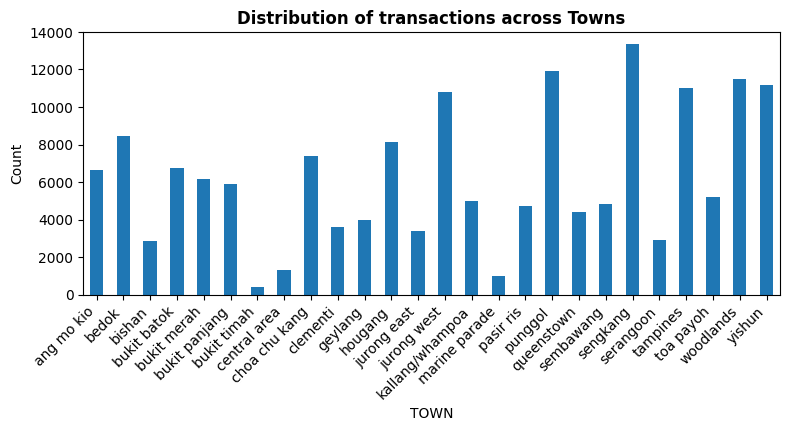

In [13]:
# Bar plots for value counts of Towns
selected_cols = ['TOWN']
for col in selected_cols:
    vc = df[col].value_counts().sort_index()
    plt.figure(figsize=(8,4))
    ax = vc.plot(kind='bar')
    # Descriptive title including sample size
    plt.title(f'Distribution of transactions across Towns', fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Count')
    # Improve xtick label alignment for readability
    ax.set_xticklabels([t.get_text() for t in ax.get_xticklabels()], rotation=45, ha='right')
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)
    plt.show()

,TOWN,avg_resale_price
0,bukit timah,759088.810175
1,bishan,699280.798663
2,central area,680658.495148
3,bukit merah,634150.980537
4,queenstown,629705.051897
5,kallang/whampoa,583412.182347
6,pasir ris,575920.373629
7,marine parade,557923.572308
8,serangoon,557697.592885
9,toa payoh,556773.708174



Top 10 towns by average RESALE_PRICE:


,TOWN,avg_resale_price
0,bukit timah,759088.810175
1,bishan,699280.798663
2,central area,680658.495148
3,bukit merah,634150.980537
4,queenstown,629705.051897
5,kallang/whampoa,583412.182347
6,pasir ris,575920.373629
7,marine parade,557923.572308
8,serangoon,557697.592885
9,toa payoh,556773.708174



Bottom 10 towns by average RESALE_PRICE:


,TOWN,avg_resale_price
0,bukit panjang,494698.473889
1,bukit batok,494133.686842
2,sembawang,493221.489205
3,choa chu kang,483608.952439
4,bedok,474894.676363
5,ang mo kio,473542.369434
6,woodlands,472046.838366
7,jurong east,469375.540725
8,jurong west,457004.013579
9,yishun,444165.965169


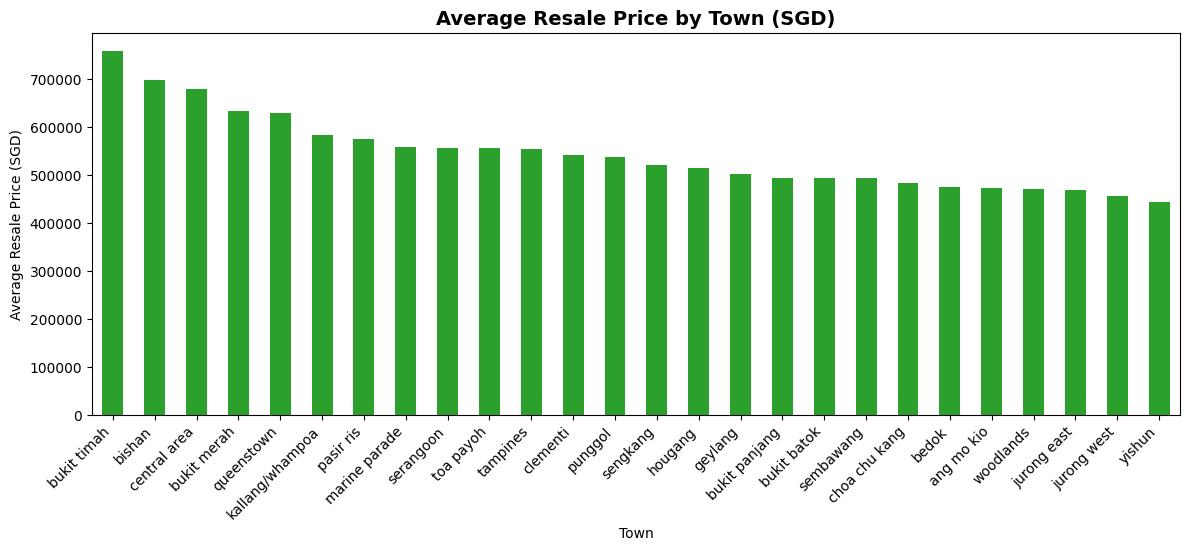

In [18]:
# Average RESALE_PRICE per Town
if 'RESALE_PRICE' in df.columns:
    # Compute mean resale price by town
    town_avg = df.groupby('TOWN')['RESALE_PRICE'].mean().sort_values(ascending=False)
    # Display as DataFrame (sorted descending)
    display(town_avg.rename('avg_resale_price').reset_index())
    
    # Print top and bottom towns for quick insight
    print('\nTop 10 towns by average RESALE_PRICE:')
    display(town_avg.head(10).rename('avg_resale_price').reset_index())
    print('\nBottom 10 towns by average RESALE_PRICE:')
    display(town_avg.tail(10).rename('avg_resale_price').reset_index())
    
    # Plot average resale price by town
    plt.figure(figsize=(12,6))
    ax = town_avg.plot(kind='bar', color='tab:green')
    ax.set_title('Average Resale Price by Town (SGD)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Average Resale Price (SGD)')
    ax.set_xlabel('Town')
    ax.set_xticklabels([t.get_text() for t in ax.get_xticklabels()], rotation=45, ha='right')
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.30)
    plt.show()
else:
    print("RESALE_PRICE column not found in DataFrame.")

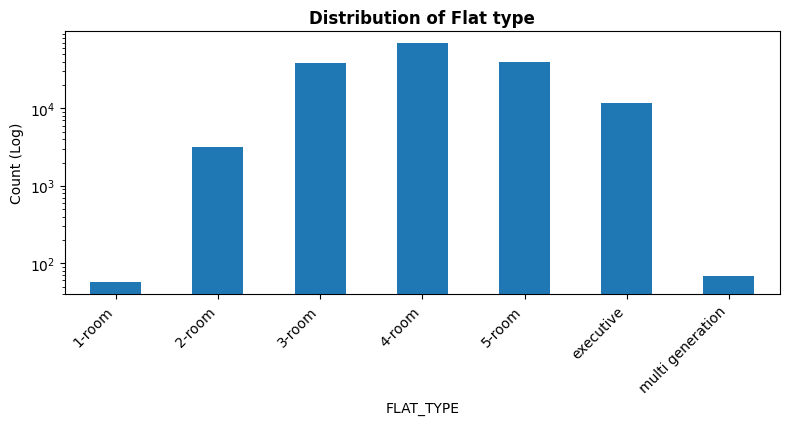

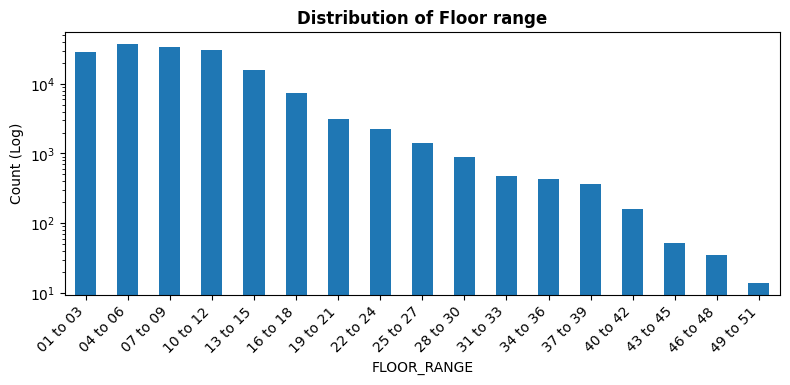

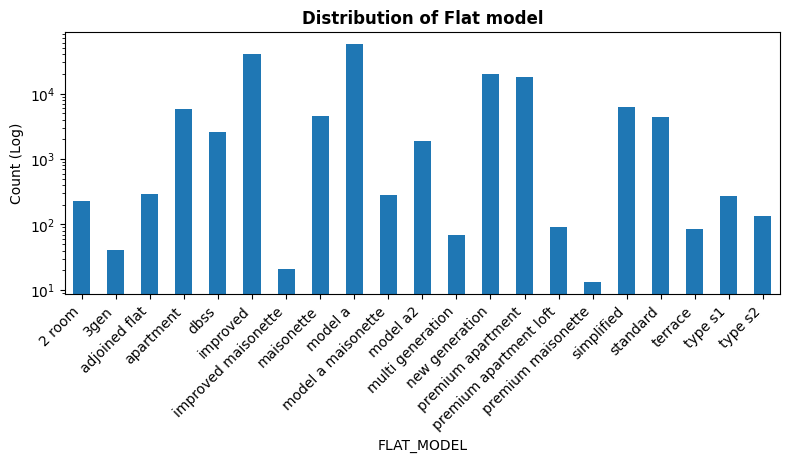

In [20]:
# Bar plots for value counts of selected non-numeric columns, sorted alphabetically
selected_cols = ['FLAT_TYPE', 'FLOOR_RANGE', 'FLAT_MODEL']
for col in selected_cols:
    vc = df[col].value_counts().sort_index()
    plt.figure(figsize=(8,4))
    ax = vc.plot(kind='bar')
    # Descriptive title including sample size
    plt.title(f"Distribution of {str(col).lower().replace('_',' ').capitalize()}", fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Count (Log)')
    plt.yscale(value="log")
    # Improve xtick label alignment for readability
    ax.set_xticklabels([t.get_text() for t in ax.get_xticklabels()], rotation=45, ha='right')
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)
    plt.show()

,FLOOR_RANGE,avg_resale_price_sgd
0,01 to 03,4.687867e+05
1,04 to 06,4.887563e+05
2,07 to 09,5.026623e+05
3,10 to 12,5.158577e+05
4,13 to 15,5.561295e+05
5,16 to 18,5.971737e+05
6,19 to 21,6.642859e+05
7,22 to 24,6.935467e+05
8,25 to 27,7.459263e+05
9,28 to 30,8.320418e+05


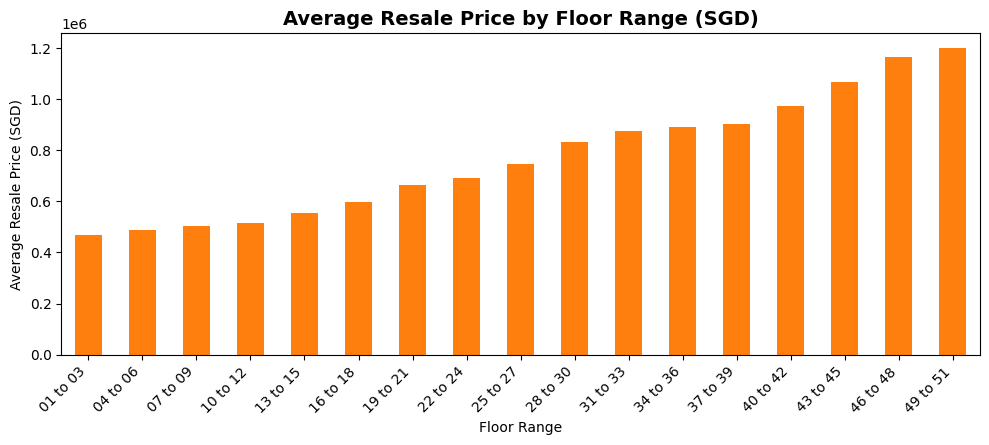

In [22]:
# Average RESALE_PRICE by FLOOR_RANGE
# Compute and plot the mean resale price grouped by FLOOR_RANGE.
# We attempt a natural ordering by extracting the lower floor number from the FLOOR_RANGE string.
if 'RESALE_PRICE' in df.columns and 'FLOOR_RANGE' in df.columns:
    fr_avg = df.groupby('FLOOR_RANGE')['RESALE_PRICE'].mean().reset_index(name='avg_resale_price')
    import re
    def _floor_lower(fr):
        if isinstance(fr, str):
            m = re.search(r'\d+', fr)
            return int(m.group(0)) if m else 10**6
        return 10**6
    fr_avg['__sort_key'] = fr_avg['FLOOR_RANGE'].apply(_floor_lower)
    fr_avg = fr_avg.sort_values('__sort_key').drop(columns=['__sort_key'])
    # Display the computed averages
    display(fr_avg.rename(columns={'avg_resale_price':'avg_resale_price_sgd'}))
    # Plot results
    plt.figure(figsize=(10,5))
    ax = fr_avg.set_index('FLOOR_RANGE')['avg_resale_price'].plot(kind='bar', color='tab:orange')
    ax.set_title('Average Resale Price by Floor Range (SGD)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Average Resale Price (SGD)')
    ax.set_xlabel('Floor Range')
    ax.set_xticklabels([t.get_text() for t in ax.get_xticklabels()], rotation=45, ha='right')
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.28)
    plt.show()
else:
    print('RESALE_PRICE or FLOOR_RANGE column not found in DataFrame.')

In [7]:
# Load external datasets
primary_schools = pd.read_csv("./data/auxiliary_data/sg-primary-schools.csv")
secondary_schools = pd.read_csv("./data/auxiliary_data/sg-secondary-schools.csv")
shopping_malls = pd.read_csv("./data/auxiliary_data/sg-shopping-malls.csv")
mrt_stations = pd.read_csv("./data/auxiliary_data/sg-mrt-stations.csv")
hdb_blocks = pd.read_csv("./data/auxiliary_data/sg-hdb-block-details.csv")

# Get unique TOWNs from main df
towns = df["TOWN"].unique()

# Count matches for each TOWN in each dataset
primary_counts = primary_schools["PLANNING_AREA"].value_counts()
secondary_counts = secondary_schools["PLANNING_AREA"].value_counts()
mall_counts = shopping_malls["PLANNING_AREA"].value_counts()
mrt_counts = mrt_stations["PLANNING_AREA"].value_counts()
hdb_counts = hdb_blocks["PLANNING_AREA"].value_counts()

# Build summary DataFrame
summary = pd.DataFrame({
    "TOWN": towns,
    "num_primary_schools": [primary_counts.get(t, 0) for t in towns],
    "num_secondary_schools": [secondary_counts.get(t, 0) for t in towns],
    "num_shopping_malls": [mall_counts.get(t, 0) for t in towns],
    "num_mrt_stations": [mrt_counts.get(t, 0) for t in towns],
    "num_hdb_blocks": [hdb_counts.get(t, 0) for t in towns]
})

display(summary)

,TOWN,num_primary_schools,num_secondary_schools,num_shopping_malls,num_mrt_stations,num_hdb_blocks
0,woodlands,12,11,1,7,689
1,bishan,3,6,2,6,227
2,bukit panjang,7,4,1,1,334
3,punggol,11,4,3,6,470
4,hougang,10,9,2,5,577
5,clementi,4,4,2,4,185
6,bedok,12,9,1,12,500
7,yishun,10,8,1,3,640
8,sengkang,11,6,2,3,618
9,queenstown,3,6,4,10,192


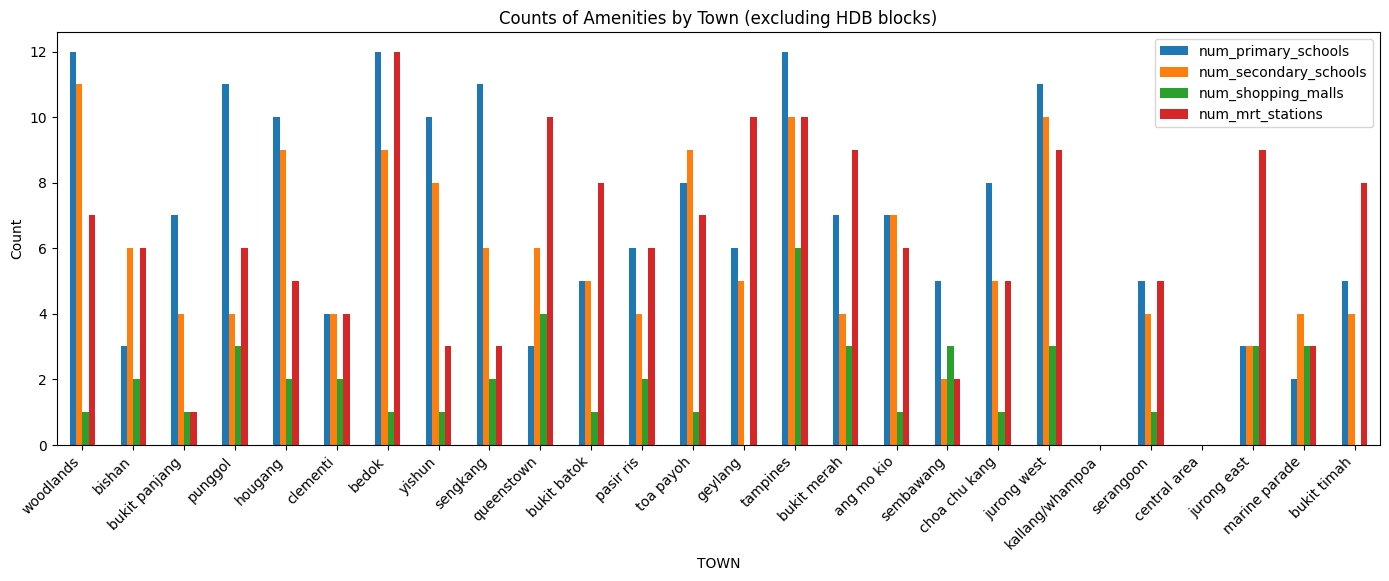

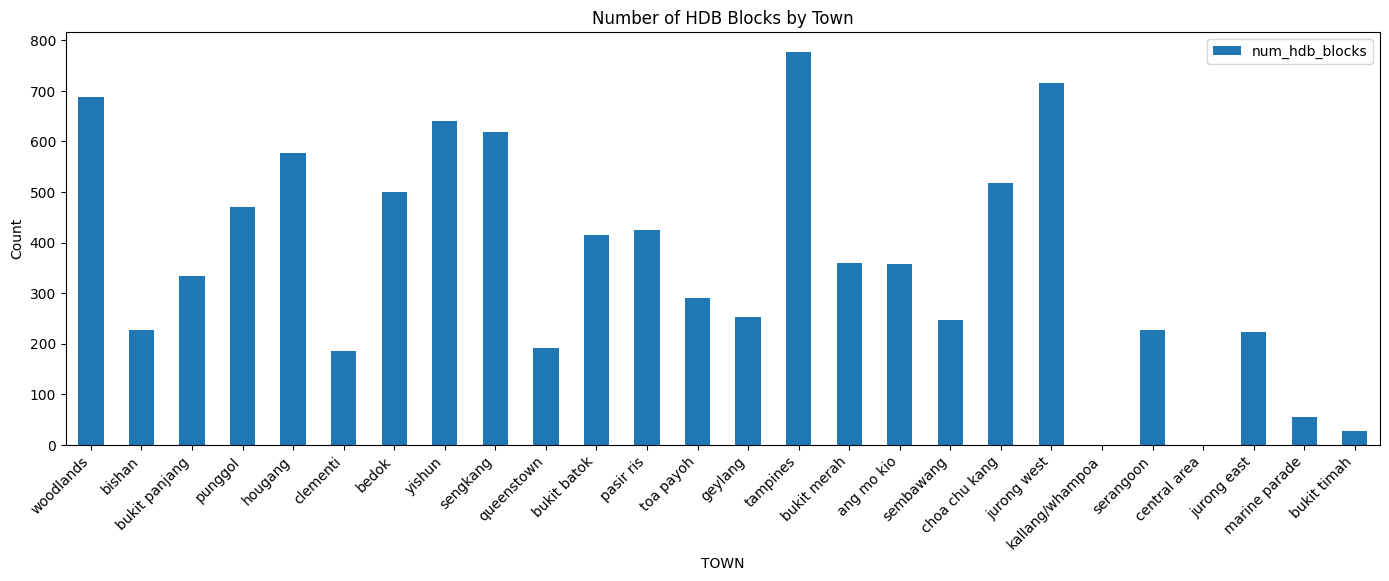

In [ ]:
# Plot the summary DataFrame

# Plot amenities (excluding HDB blocks)
ax = summary.set_index("TOWN")[["num_primary_schools", "num_secondary_schools", "num_shopping_malls", "num_mrt_stations"]].plot(
    kind="bar", figsize=(14,6)
 )
ax.set_title("Counts of Amenities by Town — Primary & Secondary Schools, Shopping Malls and MRT Stations", fontsize=14, fontweight='bold')
ax.set_ylabel("Count")
# Ensure tick labels align with the bars: set rotation and horizontal alignment on the Axes
ax.set_xticklabels([t.get_text() for t in ax.get_xticklabels()], rotation=45, ha='right')
plt.tight_layout()
# Give extra bottom margin so rotated labels don't get cut off
plt.subplots_adjust(bottom=0.28)
plt.show()

# Plot HDB blocks separately
ax2 = summary.set_index("TOWN")[["num_hdb_blocks"]].plot(
    kind="bar", figsize=(14,6), color="tab:blue"
 )
ax2.set_title("Number of HDB Blocks by Town (HDB block coverage)", fontsize=14, fontweight='bold')
ax2.set_ylabel("Count")
ax2.set_xticklabels([t.get_text() for t in ax2.get_xticklabels()], rotation=45, ha='right')
plt.tight_layout()
plt.subplots_adjust(bottom=0.28)
plt.show()